In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
print("--- Part 1: Hyperparameter Tuning with Grid Search ---")

--- Part 1: Hyperparameter Tuning with Grid Search ---


In [9]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print(f"\nDataset Features (X) shape: {X.shape}")
print(f"Dataset Labels (y) shape: {y.shape}")
print(f"Feature Names: {feature_names}")
print(f"Target Names: {target_names}")


Dataset Features (X) shape: (150, 4)
Dataset Labels (y) shape: (150,)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 105 samples
Test set size: 45 samples


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized.")


Features standardized.


In [17]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

print("\nHyperparameter grid defined:")

for param, values in param_grid.items():
    print(f"  {param}: {values}")


Hyperparameter grid defined:
  C: [0.1, 1, 10, 100]
  gamma: [1, 0.1, 0.01, 0.001]
  kernel: ['rbf', 'linear']


In [19]:
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=1
)

print("\nStarting Grid Search with 5-fold Cross-Validation...")

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed.")


Starting Grid Search with 5-fold Cross-Validation...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Grid Search completed.


In [20]:
print(f"\nBest hyperparameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Best hyperparameters found: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9810



Test set accuracy with tuned model: 0.9111

--- Classification Report for Tuned Model ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


--- Confusion Matrix for Tuned Model ---


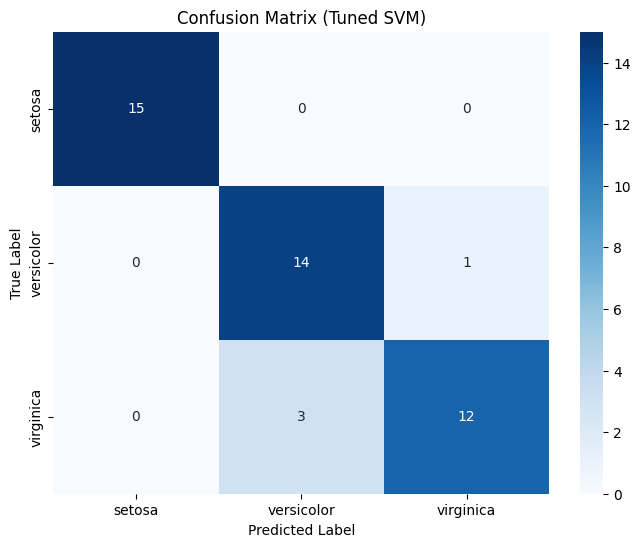

In [21]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

test_accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nTest set accuracy with tuned model: {test_accuracy_tuned:.4f}")

print("\n--- Classification Report for Tuned Model ---")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=target_names
    )
)

print("\n--- Confusion Matrix for Tuned Model ---")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Confusion Matrix (Tuned SVM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()


In [22]:
results_df = pd.DataFrame(grid_search.cv_results_)

print("\n--- Top 5 Grid Search Results ---")

print(
    results_df[
        [
            'param_C',
            'param_gamma',
            'param_kernel',
            'mean_test_score',
            'rank_test_score'
        ]
    ]
    .sort_values(by='rank_test_score')
    .head()
)


--- Top 5 Grid Search Results ---
    param_C  param_gamma param_kernel  mean_test_score  rank_test_score
10      1.0        0.100          rbf         0.980952                1
27    100.0        0.100       linear         0.980952                1
31    100.0        0.001       linear         0.980952                1
29    100.0        0.010       linear         0.980952                1
25    100.0        1.000       linear         0.980952                1


In [23]:
print("\n--- Part 2: Cross-Validation Techniques (k-fold) ---")


--- Part 2: Cross-Validation Techniques (k-fold) ---


In [24]:
model_cv = SVC(random_state=42)

In [25]:
k_folds = 5

kf = KFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

print(f"\nPerforming {k_folds}-fold cross-validation...")



Performing 5-fold cross-validation...


In [26]:
cv_scores = cross_val_score(
    model_cv,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print(f"\nCross-validation scores for each fold: {cv_scores}")

print(
    f"Mean cross-validation accuracy: "
    f"{np.mean(cv_scores):.4f}"
)

print(
    f"Standard deviation of cross-validation accuracy: "
    f"{np.std(cv_scores):.4f}"
)


Cross-validation scores for each fold: [1.         0.95238095 0.95238095 0.95238095 1.        ]
Mean cross-validation accuracy: 0.9714
Standard deviation of cross-validation accuracy: 0.0233


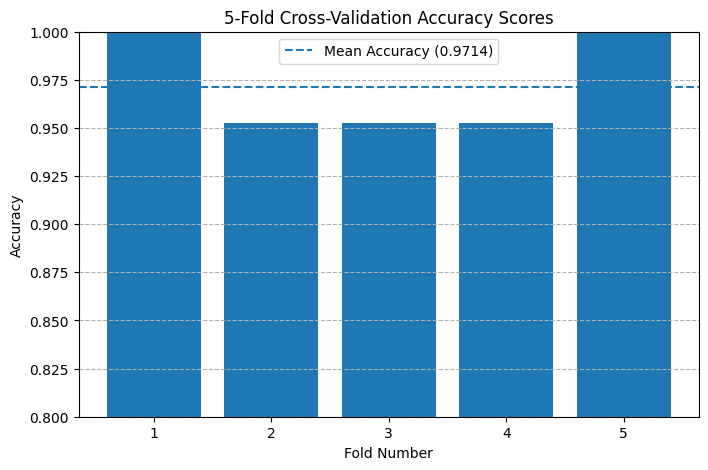

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, k_folds + 1),
    cv_scores
)

plt.axhline(
    y=np.mean(cv_scores),
    linestyle='--',
    label=f'Mean Accuracy ({np.mean(cv_scores):.4f})'
)

plt.title(f'{k_folds}-Fold Cross-Validation Accuracy Scores')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.ylim(0.8, 1.0)

plt.legend()

plt.grid(axis='y', linestyle='--')

plt.show()


In [28]:
print("\n--- Why is Cross-Validation Important? ---")

print("1. More Reliable Performance Estimate: Reduces bias from a single train-test split.")
print("2. Better Generalization: Helps ensure the model performs well on unseen data.")
print("3. Efficient Data Usage: All data points are used for both training and validation across different folds.")
print("4. Detects Overfitting/Underfitting: Variability in scores can indicate instability.")


--- Why is Cross-Validation Important? ---
1. More Reliable Performance Estimate: Reduces bias from a single train-test split.
2. Better Generalization: Helps ensure the model performs well on unseen data.
3. Efficient Data Usage: All data points are used for both training and validation across different folds.
4. Detects Overfitting/Underfitting: Variability in scores can indicate instability.
